In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import roc_curve
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import recall_score, precision_score

# Загрузка данных

In [2]:
data = pd.read_csv('athletes.csv')
data.head()

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze
0,736041664,A Jesus Garcia,ESP,male,10/17/69,1.72,64.0,athletics,0,0,0
1,532037425,A Lam Shin,KOR,female,9/23/86,1.68,56.0,fencing,0,0,0
2,435962603,Aaron Brown,CAN,male,5/27/92,1.98,79.0,athletics,0,0,1
3,521041435,Aaron Cook,MDA,male,1/2/91,1.83,80.0,taekwondo,0,0,0
4,33922579,Aaron Gate,NZL,male,11/26/90,1.81,71.0,cycling,0,0,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  object 
 2   nationality  11538 non-null  object 
 3   sex          11538 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  object 
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 991.7+ KB


Есть пропуски в столбцах dob, height и weight.

# Заполнение пропусков

In [4]:
data.loc[data['height'].isna()].head()

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze
12,258556239,Abbas Qali,IOA,male,10/11/92,NaN,NaN,aquatics,0,0,0
47,469953606,Abdoullah Bamoussa,ITA,male,6/8/86,NaN,NaN,athletics,0,0,0
50,325809293,Abdul Omar,GHA,male,10/3/93,NaN,NaN,boxing,0,0,0
52,262868423,Abdulaziz Alshatti,IOA,male,10/30/90,NaN,NaN,fencing,0,0,0
56,897549624,Abdullah Hel Baki,BAN,male,8/1/89,NaN,NaN,shooting,0,0,0


In [5]:
data.loc[data['name'] == 'Abbas Qali']

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze
12,258556239,Abbas Qali,IOA,male,10/11/92,NaN,NaN,aquatics,0,0,0


Заполнение пропусков в столбце height

In [6]:
#заполнение средним в соответствии с полом и национальностью
data['height_fill'] = data.groupby(['sex','nationality'])['height'].transform(lambda x: x.fillna(x.mean()))

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  object 
 2   nationality  11538 non-null  object 
 3   sex          11538 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  object 
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
 11  height_fill  11494 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 1.1+ MB


In [8]:
#т.к. заполнились не все пропуски, заполним средним только по полу
data['height_fill'] = data.groupby(['sex'])['height'].transform(lambda x: x.fillna(x.mean()))

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  object 
 2   nationality  11538 non-null  object 
 3   sex          11538 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  object 
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
 11  height_fill  11538 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 1.1+ MB


Заполнение пропусков в столбце weight

In [10]:
#заполнение средним в соответствии с полом и национальностью
data['weight_fill'] = data.groupby(['sex','nationality'])['weight'].transform(lambda x: x.fillna(x.mean()))

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  object 
 2   nationality  11538 non-null  object 
 3   sex          11538 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  object 
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
 11  height_fill  11538 non-null  float64
 12  weight_fill  11484 non-null  float64
dtypes: float64(4), int64(4), object(5)
memory usage: 1.1+ MB


In [12]:
#т.к. заполнились не все пропуски, заполним средним только по полу
data['weight_fill'] = data.groupby(['sex'])['weight'].transform(lambda x: x.fillna(x.mean()))

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  object 
 2   nationality  11538 non-null  object 
 3   sex          11538 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  object 
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
 11  height_fill  11538 non-null  float64
 12  weight_fill  11538 non-null  float64
dtypes: float64(4), int64(4), object(5)
memory usage: 1.1+ MB


In [14]:
#остается один пропуск в столюце с датой рождения
data.loc[data['dob'].isna()].head()

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze,height_fill,weight_fill
8546,663676373,Pavel Sozykin,RUS,male,NaN,NaN,NaN,sailing,0,0,0,1.820965,80.1008


Поле с датой рождения в данном случае можно заполнить фактом, т.к. дата рождения Павла Созыкина известна - 25 декабря 1987.
Но данное поле не влияет на результат модели, дата рождения никак не влияет на пол спортмена и данное поле будет не корректно переводить как категориальное в числовой признак, т.к. не является фактически ни категориальным, ни числовым.

Поле можно удалить, также удалим исходные поля с пропусками height, weight.
Также необходимо удалить поле name и id, т.к. не влияют на пол.

In [15]:
data = data.drop(['id','dob','height','weight','name'], axis = 1)

In [16]:
data.head()

,nationality,sex,sport,gold,silver,bronze,height_fill,weight_fill
0,ESP,male,athletics,0,0,0,1.72,64.0
1,KOR,female,fencing,0,0,0,1.68,56.0
2,CAN,male,athletics,0,0,1,1.98,79.0
3,MDA,male,taekwondo,0,0,0,1.83,80.0
4,NZL,male,cycling,0,0,0,1.81,71.0


# Перекодирование категорильных признаков

In [17]:
#датасет с признаками
features_columns = [c for c in data.columns if c != 'sex']
X = data[features_columns]
X.head(3)

,nationality,sport,gold,silver,bronze,height_fill,weight_fill
0,ESP,athletics,0,0,0,1.72,64.0
1,KOR,fencing,0,0,0,1.68,56.0
2,CAN,athletics,0,0,1,1.98,79.0


In [18]:
#целевая переменная
y = data['sex']

In [19]:
le = LabelEncoder()

In [20]:
le.fit( data['sex'] )

LabelEncoder()

In [21]:
#преобразуем целевую переменную в значения 1 и 0
y = pd.Series( data = le.transform( data['sex'] ) )
y.head()

0    1
1    0
2    1
3    1
4    1
dtype: int32

In [22]:
y.unique()

array([1, 0])

In [23]:
#Преобразуем остальные категориальные переменные в числовые
X = pd.get_dummies(X, columns=['nationality','sport'])

In [24]:
X.columns

Index(['gold', 'silver', 'bronze', 'height_fill', 'weight_fill',
       'nationality_AFG', 'nationality_ALB', 'nationality_ALG',
       'nationality_AND', 'nationality_ANG',
       ...
       'sport_rugby sevens', 'sport_sailing', 'sport_shooting',
       'sport_table tennis', 'sport_taekwondo', 'sport_tennis',
       'sport_triathlon', 'sport_volleyball', 'sport_weightlifting',
       'sport_wrestling'],
      dtype='object', length=240)

# Разделение выборки на train и test. Построение модели.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
model = LogisticRegression()

In [27]:
model.fit(X_train, y_train)

C:\Users\79136\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [28]:
model.score(X_test, y_test)

0.8193240901213171

In [29]:
model.score(X_train, y_train)

0.8359696641386782

# Построение ROC-кривой с помощью функции roc_curve из библиотеки sklearn.metrics.

In [30]:
predictions = model.predict_proba(X_test)

In [31]:
fpr, tpr, thres = roc_curve( y_test, predictions[:, 1])

In [32]:
predictions[:, 1]

array([0.97917971, 0.53331082, 0.91432073, ..., 0.53029421, 0.11423604,
       0.91929988])

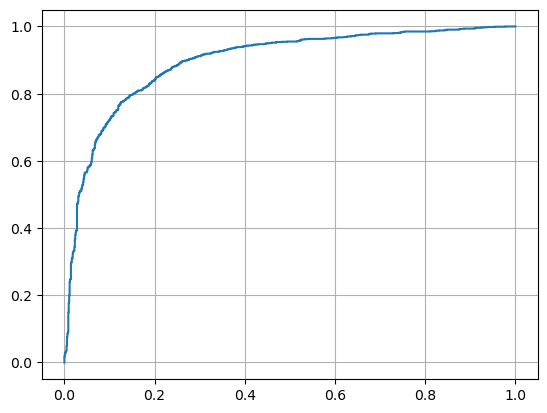

In [33]:
plt.plot(fpr, tpr)
plt.grid()

# Вычисление значения ROC-AUC метрики с помощью функции roc_auc_score из библиотеки sklearn.metrics.

In [34]:
roc_auc_score(y_test, predictions[:, 1])

0.8963003034080486

In [35]:
pred = model.predict(X_test)

In [36]:
recall_score(y_test, pred)

0.8221872541306058

In [37]:
precision_score(y_test, pred)

0.8454692556634305

# Реализация подсчета метрик TPR, FPR «вручную», без использования готовых функций из библиотеки sklearn.

In [38]:
tp = 0 # True positive
fp = 0 # False positive
fn = 0 # False negative
tn = 0 # True negative

predictions = model.predict_proba(X_test)
for predicted_prob, actual in zip(predictions[:, 1], y_test):
    if predicted_prob >= 0.5:
        predicted = 1
    else:
        predicted = 0

    if predicted == 1:
        if actual == 1:
            tp += 1
        else:
            fp += 1

    else:
        if actual == 1:
            fn += 1
        else:
            tn += 1

In [39]:
tp, fp, fn, tn

(1045, 191, 226, 846)

In [40]:
(tp + tn) / (tp + fp + fn + tn)

0.8193240901213171

Значение рассчитанное вручную совпадает с подсчитанным функцией из библиотеки

# TPR = TP / (TP + FN), FPR = FP / (FP + TN)

In [41]:
tpr_manual = tp/(tp+fn)
fpr_manual = fp/(fp+tn)

In [42]:
print('TPR_manual',end=": ")
print(tpr_manual)
print('FPR_manual',end=": ")
print(fpr_manual)

TPR_manual: 0.8221872541306058
FPR_manual: 0.18418514946962392


In [43]:
thresholds_manual = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
tpr_list = []
fpr_list = []
recall_list = []
precision_list = []

for threshold in thresholds_manual:
    # Получение предсказаний для заданного порога
    y_pred_manual = (predictions[:, 1] >= threshold).astype(int)
    
    #расчет значений для матрицы
    TP = np.sum((y_test == 1) & (y_pred_manual == 1))
    FP = np.sum((y_test == 0) & (y_pred_manual == 1))
    TN = np.sum((y_test == 0) & (y_pred_manual == 0))
    FN = np.sum((y_test == 1) & (y_pred_manual == 0))
    
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0  
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0 
    PRECISION = TP / (TP + FP) if (TP + FP) > 0 else 0 
    RECALL = TP / (TP + FN) if (TP + FN) > 0 else 0  

    
    #добавление в список посчитанных значений
    tpr_list.append(TPR)
    fpr_list.append(FPR)
    recall_list.append(RECALL)
    precision_list.append(PRECISION)

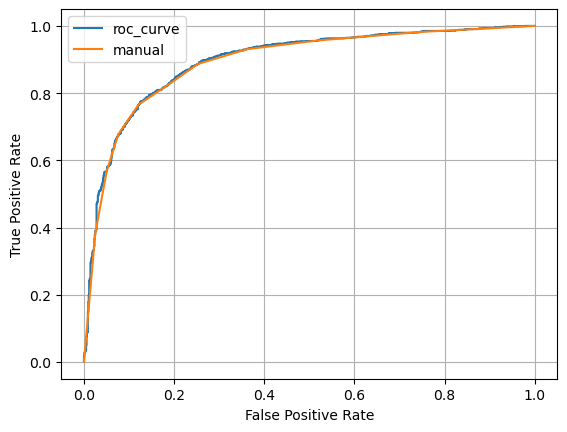

In [44]:
plt.plot(fpr, tpr, label = 'roc_curve')
plt.plot(fpr_list, tpr_list, label = 'manual')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc=0)
plt.grid()
plt.show()

Вывод по графику:

При ручном подсчете и автоматизированном графики проходят очень близко друг к другу, на автоматизированном больше колебаний, т.к. учитывается большее количество шагов, а не 0.1 как при ручном.

# Построение графика Precision-Recall, используя метрики, посчитанные в п. 5.

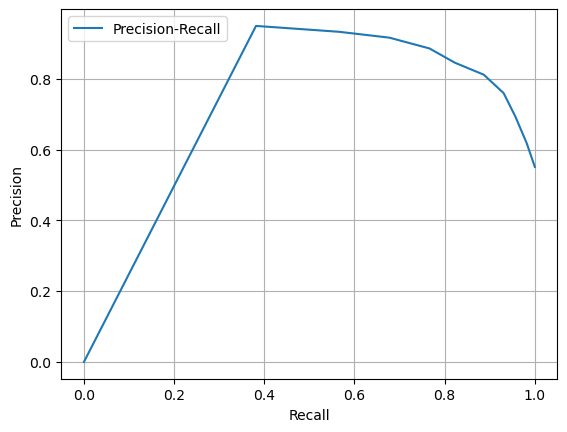

In [45]:
plt.plot(recall_list, precision_list, label = 'Precision-Recall')
plt.xlabel('Recall')
plt.ylabel('Precision')

plt.legend(loc=0)
plt.grid()
plt.show()

In [46]:
recall_list

[1.0,
 0.981904012588513,
 0.956726986624705,
 0.930763178599528,
 0.8867033831628639,
 0.8221872541306058,
 0.7663257277734068,
 0.6774193548387096,
 0.5656963021243115,
 0.3815892997639654,
 0.0]

In [47]:
precision_list

[0.5506932409012132,
 0.6178217821782178,
 0.69327251995439,
 0.7593068035943518,
 0.8113750899928006,
 0.8454692556634305,
 0.8854545454545455,
 0.9159574468085107,
 0.9325551232166018,
 0.949119373776908,
 0]

Вывод:
    
На тестовых данных данных модель показывает высокий результат, почти 0.84, на тренировочных 0.82.

ROC-AUC (площадь под кривой) также имеет высокое значение 0.9, что говорит о том о том, что модель хорошо определяет классы (вероятность отнесения к классу).

Precision (точность) — показывает, какая доля объектов, выделенных как положительные, действительно являются положительными. 

Recall (полнота) — измеряет долю верно предсказанных положительных случаев среди всех реальных положительных.

Из графика видно, что увеличивая Recall (к 100% верно указанных положительных случаев), снижается показатель Precision, т.к. изменяя границу, с верными значениями начинают попадать и не верные.

Так например, посчитав, что все объекты принадлежат к классу 1, получаем recall равный 1, а Precision равен при этом 0.55, т.е. только 55% из них являются действительно положительными. Что также говорит о том, что классы сбалансированы.